# Building an epigenetic methylation clock with scikit-learn

Reference articles:
- Horvath, Genome Biology 2013: https://genomebiology.biomedcentral.com/articles/10.1186/gb-2013-14-10-r115#MOESM21
- Varshavsky et al. Cell Reports Methods 2023: https://www.cell.com/cell-reports-methods/fulltext/S2667-2375(23)00211-4


# Data loading & inspection

In [63]:
local = True

if not local:
    from google.colab import drive
    drive.mount('/content/drive')

In [64]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

if local:
    folder = 'data/'
else:
    folder = "/content/drive/MyDrive/University/Computation Biology/Ex1 Data"
datasets = [ x for x in os.listdir(folder) if x.endswith('.csv') and x.startswith('GSE')]

tables = []

for dataset in datasets:
    name = dataset.split('.')[0]
    table = pd.read_csv(os.path.join(folder,dataset),index_col=0).transpose()
    table['Source'] = name
    print(dataset,table.shape)
    tables.append(table)

full_table = pd.concat(tables,axis=0,join='outer')


methylation_site_names = [x for x in full_table.columns if x not in ['age','Source']]

if os.path.exists(os.path.join(folder, 'site_annotations.csv')):
    methylation_site_annotations = pd.read_csv(os.path.join(folder, 'site_annotations.csv'),index_col=0)
else:
    methylation_site_annotations = pd.read_csv('humanmethylation450_15017482_v1-2.csv',skiprows=7,index_col='IlmnID')
    methylation_site_annotations = methylation_site_annotations.loc[methylation_site_names][['CHR','MAPINFO','Strand','SourceSeq','UCSC_RefGene_Name']]
    methylation_site_annotations.to_csv(os.path.join(folder, 'site_annotations.csv'))


GSE72680.csv (422, 1048)
GSE157131.csv (1218, 2280)
GSE55763.csv (2639, 2376)
GSE154566.csv (235, 936)
GSE69270.csv (184, 981)
GSE147221.csv (679, 2376)
GSE73103.csv (355, 979)
GSE64495.csv (113, 2376)
GSE40279.csv (656, 2376)
GSE42861.csv (689, 2376)
GSE87648.csv (382, 2351)
GSE36054.csv (134, 2376)
GSE41169.csv (95, 2376)
GSE72775.csv (335, 2376)
GSE51032.csv (845, 2376)
GSE105018.csv (1658, 1026)
GSE103657.csv (586, 995)
GSE84727.csv (665, 1027)
GSE30870.csv (20, 2376)


## Inspecting the dataset

Pay attention that for some individuals, not all methylation levels were measured.

In [65]:
full_table.head()

,age,cg00058879,cg00059225,cg00080081,cg00094518,cg00101260,cg00103778,cg00129827,cg00144180,cg00145253,...,ch.5.432310R,ch.5.79606571R,ch.6.2925136R,ch.6.41978480R,ch.7.135065R,ch.7.2635062R,ch.7.2986028F,ch.7.3189261R,ch.8.103893680R,ch.9.1059422R
GSM1868353,70.0,0.252,0.521,0.065,0.211,0.205,0.246,0.108,0.944,0.310,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM1868174,22.0,0.215,0.417,0.155,0.069,0.245,0.385,0.243,0.797,0.210,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM1868180,21.0,0.046,0.326,0.183,0.022,0.319,0.267,0.211,0.833,0.210,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM1868183,43.0,0.137,0.433,0.103,0.092,0.291,0.331,0.208,0.901,0.285,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM1946528,44.0,0.160,0.463,0.130,0.118,0.279,0.267,0.207,0.830,0.280,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
print(full_table.shape)

(11910, 2376)


## Inspecting the metadata for each methylation site.
- IlmnID: Name.
- CHR: Chromosome.
- MAPINFO: start position along the reference genome.
- STRAND: on which strand is the CpG site located.
- Source: The corresponding DNA fragment

In [67]:
methylation_site_annotations.head()

,CHR,MAPINFO,Strand,SourceSeq,UCSC_RefGene_Name
IlmnID,,,,,
cg00058879,22.0,40082173.0,F,GGGCGGCCAGGCTGCTGGTGCTGCTGAACTTCCTGGCGGGCGTGAG...,CACNA1I;CACNA1I
cg00059225,5.0,151304357.0,F,GCAGGGAGCCAACAGACACGCTGGAGTTTAACAAACAGCAATACTC...,GLRA1;GLRA1;GLRA1;GLRA1
cg00080081,17.0,33701776.0,F,CGCACGTTTGTTAAAATGAGGTCATAATGTTCATGCTGTTTCATAA...,SLFN11;SLFN11;SLFN11;SLFN11;SLFN11
cg00094518,7.0,130418549.0,F,TCTGGGCGGACTTGCGCGGCAGCTCTGGCGAGGGCTCCTGGGAGAA...,KLF14
cg00101260,17.0,53426657.0,R,CGGTTCCAATGAAGCGTGGAGCATCTGTGATTCCAATCCTGAGGGG...,NaN


In [68]:
methylation_site_annotations.tail()

,CHR,MAPINFO,Strand,SourceSeq,UCSC_RefGene_Name
IlmnID,,,,,
ch.7.2635062R,7.0,127719998.0,F,CAGCTCTTCCAGGGGCACTTTGGCATTGACTAGGTATCCCTGAGAA...,SND1
ch.7.2986028F,7.0,141887997.0,F,CAGACAACACAGGTCTGCTTTGGATCTGATCAGATGGACTAAATCT...,LOC100124692
ch.7.3189261R,7.0,151489100.0,F,CAGGACATGCTTGCTACTGTCTGATTCTCTGGCATTGGGCAAATGA...,PRKAG2;PRKAG2
ch.8.103893680R,8.0,103824504.0,F,CAGCAGTCAGCTTTGAAGGAGCAAAACATGGTGCTACAGAACATGT...,NaN
ch.9.1059422R,9.0,83693653.0,F,CAGCAGCAGACCACAACAGCTGAGAACTTGGCTGTTGAAGTCAAAC...,NaN


# Part I: Exploratory Data Analysis

1.	For each CpG site, calculate the Spearman correlation coefficient between its methylation level and the age of the donor. Display the result as a histogram and comment on the findings.


In [69]:
print(full_table['age'].isna().any())

False


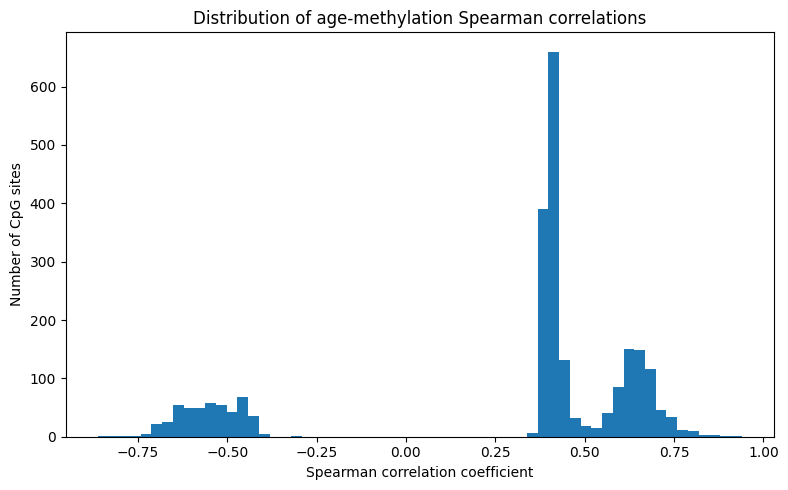

In [70]:
corrs = full_table[methylation_site_names].corrwith(full_table["age"], method="spearman").dropna()

plt.figure(figsize=(8, 5))
plt.hist(corrs, bins=60)
plt.xlabel("Spearman correlation coefficient")
plt.ylabel("Number of CpG sites")
plt.title("Distribution of age-methylation Spearman correlations")
plt.tight_layout()
plt.show()

The results are not surprising - as the hw mentioned, this is a dataset already limited:
"The 450K sites were already trimmed down to ~2375 CpG sites that are correlated with aging"

This shows in the data - all the cpg sites are correlative to some degree, and there is a hole from -0.25 to 0.25.

On top of that, we can also see that some sites are correlated positively and some negatively, suggesting that methylation in some sites causes/is caused by aging, and for other methylation is removed in the same condition, which means we should be careful in further analysis to not assume aging->increased methylation for every site. Some sites are positively correlated with age (methylation accumulates over time) and others are negatively correlated (methylation is lost over time). Both directions reflect age-related changes, so we shouldn't assume that aging uniformly increases methylation. When interpreting the model later, the sign of each coefficient matters.

2.	For the 5 CpG sites with highest and lowest Spearman correlation coefficient values, visualize the relationship between methylation level and age using a scatter plot. Comment on the findings.



In [71]:
print(corrs)

cg00058879         0.622965
cg00059225         0.756109
cg00080081        -0.516912
cg00094518         0.713521
cg00101260        -0.581767
                     ...   
ch.7.2635062R     -0.446936
ch.7.2986028F     -0.454754
ch.7.3189261R     -0.461569
ch.8.103893680R   -0.448639
ch.9.1059422R     -0.437972
Length: 2374, dtype: float64


In [72]:
selected_sites= list(corrs.nsmallest(5).index) + list(corrs.nlargest(5).index)
print(selected_sites)

['cg19283806', 'cg26685941', 'cg08128734', 'cg05412028', 'cg00573770', 'cg16867657', 'cg22454769', 'cg06639320', 'cg21572722', 'cg04875128']


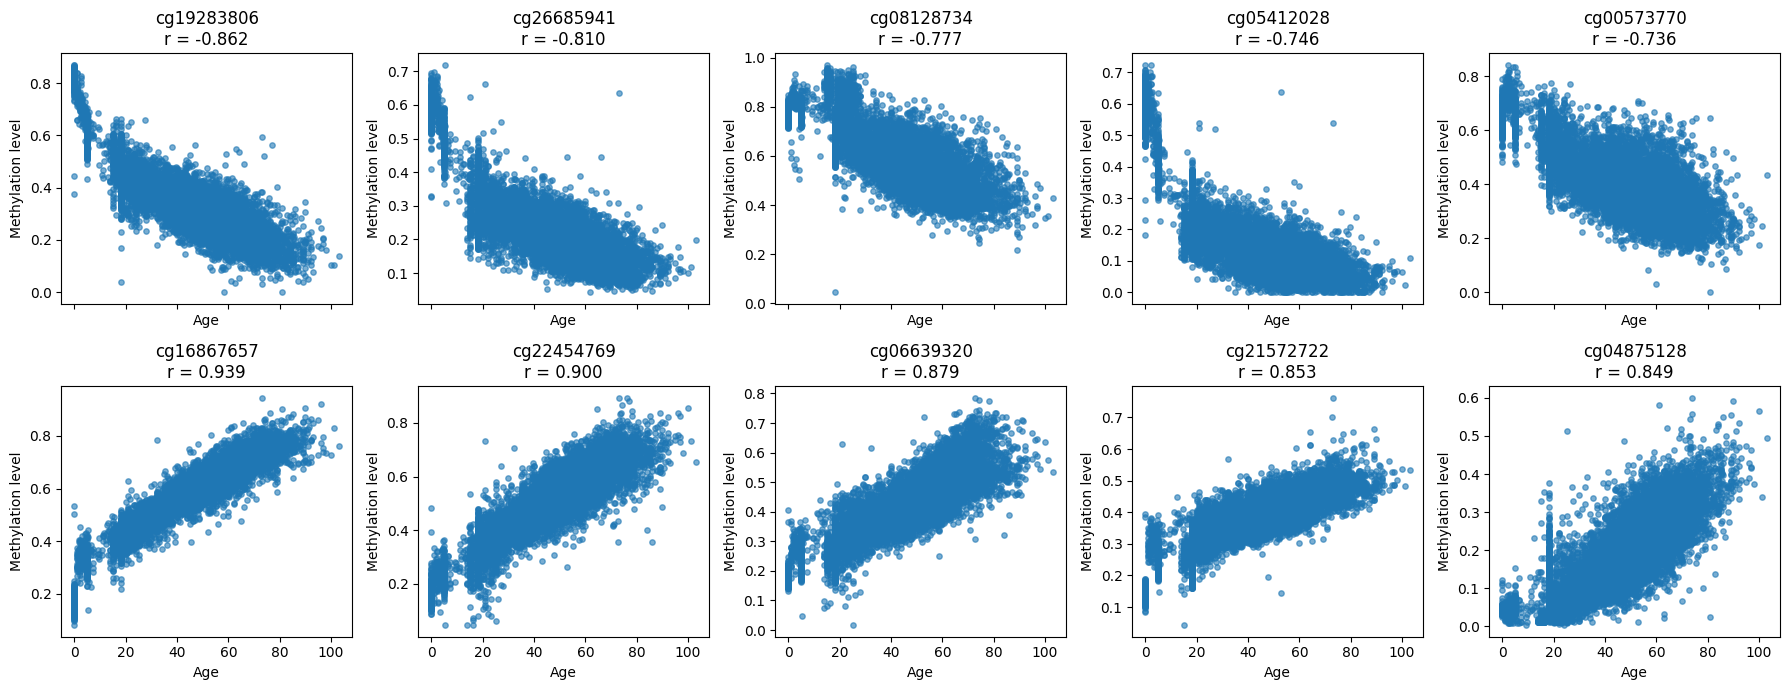

In [73]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True)
axes = axes.flatten()

for ax, site in zip(axes, selected_sites):
    plot_df = full_table[["age", site]].dropna()

    ax.scatter(plot_df["age"], plot_df[site], alpha=0.6, s=15)
    ax.set_title(f"{site}\nr = {corrs[site]:.3f}")
    ax.set_xlabel("Age")
    ax.set_ylabel("Methylation level")

plt.tight_layout()
plt.show()

The plots seem pretty standard - very straightforward increase for the positives and decrese for the negatives.

The only thing that is somewhat unusual is the straight lines that are in the start or middle left of the plots, which we assume could be due to some ages being very popular in the study/the sequencing machine varying strongly for weak signals

3.	Select all sites located along Chromosome 10 and reorder them by their location along the genome. Calculate the matrix of Spearman correlation coefficients between all pairs of methylation levels and visualize as a heatmap. Comment on the findings.


In [74]:
chr10_sites = methylation_site_annotations[methylation_site_annotations["CHR"] == 10].sort_values("MAPINFO").index

chr10_sites = [site for site in chr10_sites if site in methylation_site_names]

chr10_methylation = full_table[chr10_sites]

chr10_corr_matrix = chr10_methylation.corr(method="spearman")

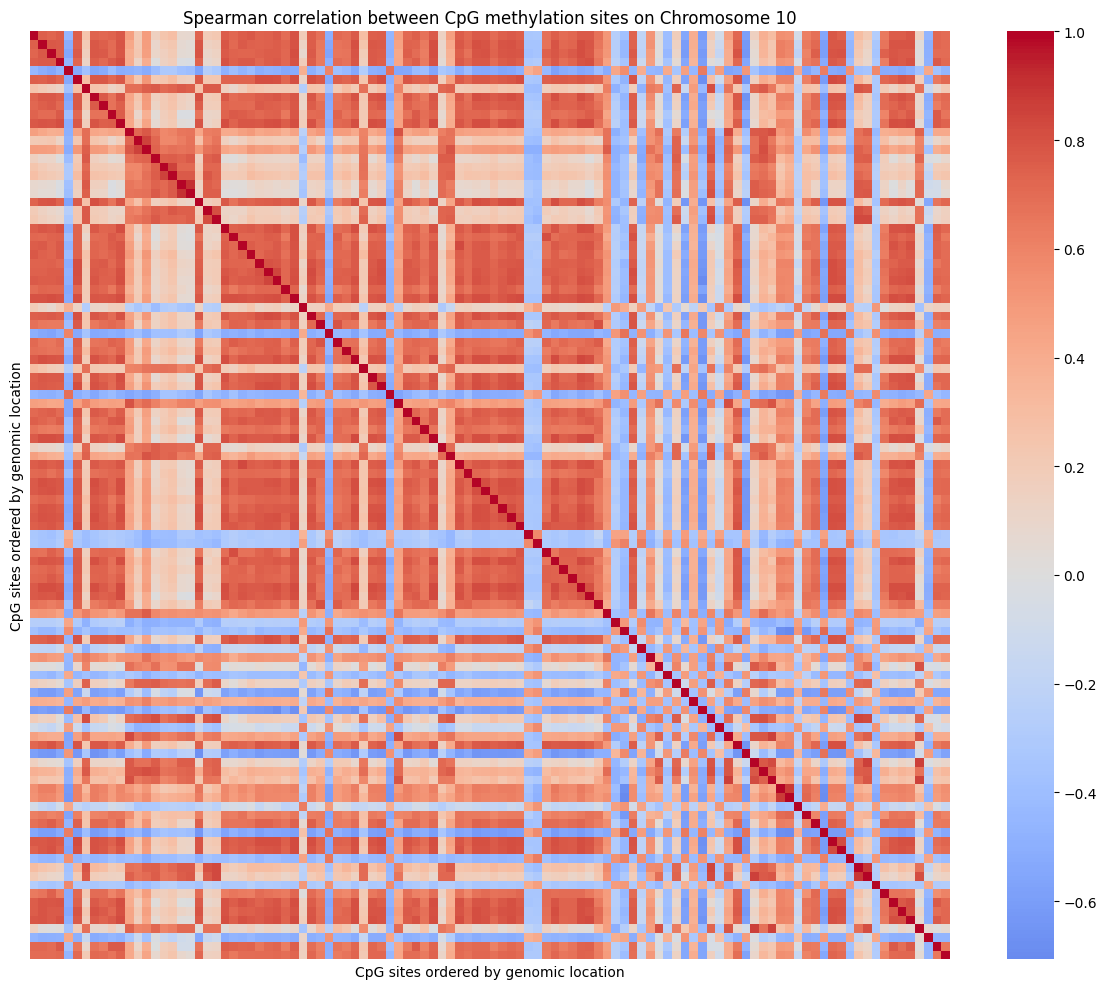

In [75]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    chr10_corr_matrix,
    cmap="coolwarm",
    center=0,
    xticklabels=False,
    yticklabels=False
)
plt.title("Spearman correlation between CpG methylation sites on Chromosome 10")
plt.xlabel("CpG sites ordered by genomic location")
plt.ylabel("CpG sites ordered by genomic location")
plt.tight_layout()
plt.show()

The findings are rather interesting. The heatmap creates square shapes which means that many areas are closely connected within themselves, and very weakly correalated with areas between these squares. this could be due to spacial correlation - if one site in an area is methylated, so do those around it

# Part II: Data Partition

Here, we perform the data partition, splitting the dataset into a training and a test set. We then split the training set into five folds for cross-validation purpose.

- The dataset was compiled from 19 separate studies. To account for potential "batch effects" (i.e., distribution shift from one study to the other), we use one of the study as test set.

- For the cross-validation, we use a stratified K-fold approach.

In [76]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer
X , Y = full_table[methylation_site_names], full_table['age']
study = full_table['Source'] # The study chosen from.

test_set = (study == 'GSE84727')

X_train, Y_train = X[~test_set], Y[~test_set]
X_test, Y_test = X[test_set], Y[test_set]


Y_train_binned = KBinsDiscretizer(n_bins=20,encode='ordinal').fit_transform(Y_train.to_numpy()[:,None])[:,0]
skf = StratifiedKFold(n_splits=5,random_state=0,shuffle=True)
skf.get_n_splits(X_train,Y_train_binned)

/Users/almogtavor/Documents/code/un/computational-biology/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/almogtavor/Documents/code/un/computational-biology/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


5

4.	Report the number of samples per study and visualize the age distribution for each of the 19 studies, using a boxplot. Comment on the findings.



,Study,Number of samples
0,GSE103657,586
1,GSE105018,1658
2,GSE147221,679
3,GSE154566,235
4,GSE157131,1218
5,GSE30870,20
6,GSE36054,134
7,GSE40279,656
8,GSE41169,95
9,GSE42861,689


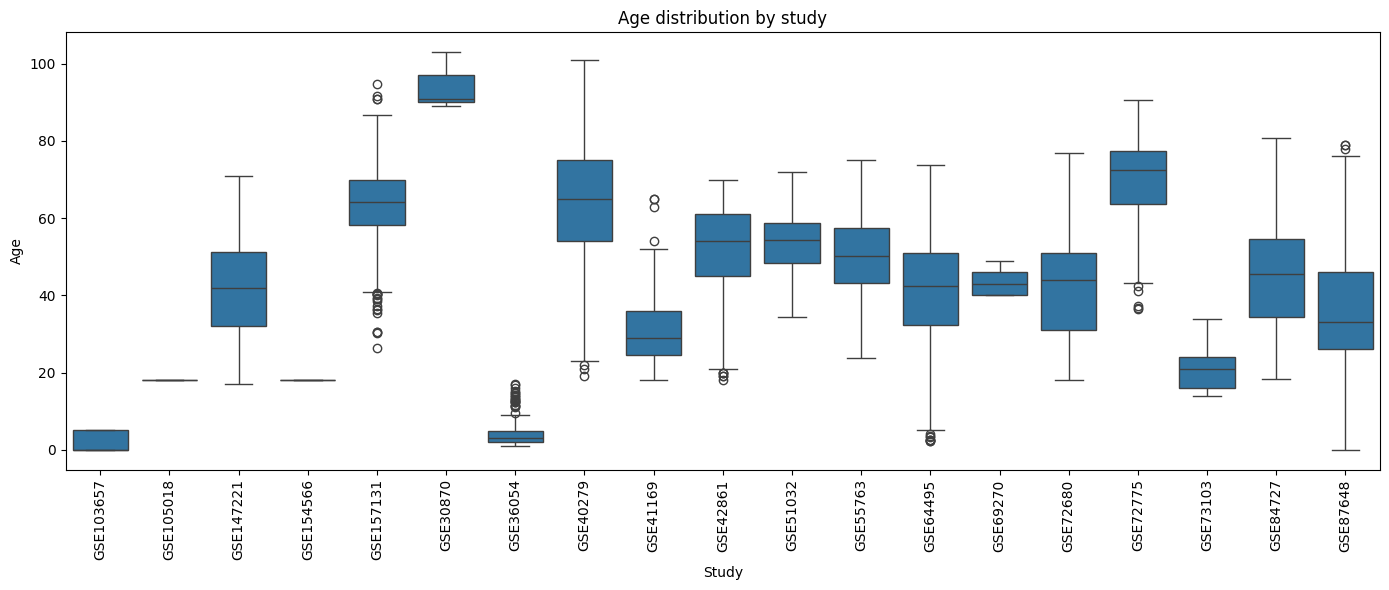

In [77]:
study_age_df = full_table[["Source", "age"]].dropna()

sample_counts = (
    study_age_df["Source"]
    .value_counts()
    .sort_index()
    .rename_axis("Study")
    .reset_index(name="Number of samples")
)

display(sample_counts)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=study_age_df,
    x="Source",
    y="age",
    order=sample_counts["Study"]
)
plt.xticks(rotation=90)
plt.xlabel("Study")
plt.ylabel("Age")
plt.title("Age distribution by study")
plt.tight_layout()
plt.show()

It seems that while most studies have focused on a wide variety of ages around 40 to 80, some studies have in particular focused on young/old poplulations.

We should be careful when predicting for those since they can behave differently/be affected by different biology.

It should also be noted that the whiskers of the studies' ages is quite big, and that some studies have many outliers.

5.	Read how the partition between train and test was done on the notebook.
a.	Why did we use dataset “GSE84727” as a test set rather than by using a random split?  
b.	Why did we use a stratified split for the training set rather than a random split or a grouped split?


a. We use this dataset because it is diverse and stable - it has no severe outliers, and its median age is quite close to the median of all the studies. it has an "avverage" population

b. Using a stratified split was important to keep the age distribution in the validation set consistant and balanced. We wanted to avoid a case in which the validation set accidentally contains for example only young patients, which might have different biology than older ones - a case which would make our model fail on them/not study properly.

# Part III: Training and evaluating a linear model

Build a scikit-learn Pipeline consisting of:
-	An imputer for missing values (SimpleImputer)
-	Top-K feature selection using the F-statistics of the correlation coefficient (functions: SelectKBest and f_regression).
-	Ridge Regression.
For each of the following values of K: [5,10,20,30,50,100,500,1000], select the optimal L2 regularization strength over the range by cross-validation.

6.	Report the performance of the model on the test set as a table with error bars (defined as the standard deviation of the absolute error, divided by the square root of the test set size).
How does the performance evolve with K?


In [78]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

k_values = [5, 10, 20, 30, 50, 100, 500, 1000]
alpha_values = np.logspace(-2, 6, 17)

In [79]:
cv_splits = list(skf.split(X_train, Y_train_binned))
results = []
best_models = {}

In [80]:
for k in k_values:
    pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("selector", SelectKBest(score_func=f_regression, k=k)), ("model", Ridge())])

    grid = GridSearchCV(estimator=pipe, param_grid={"model__alpha": alpha_values}, scoring="neg_mean_absolute_error", cv=cv_splits)

    grid.fit(X_train, Y_train)

    y_pred = grid.predict(X_test)
    abs_errors = np.abs(Y_test - y_pred)

    # mae= mean absolute errorr
    test_mae = mean_absolute_error(Y_test, y_pred)
    test_error_bar = abs_errors.std(ddof=1) / np.sqrt(len(abs_errors))

    results.append({"K": k, "best_alpha": grid.best_params_["model__alpha"], "cv_mae": -grid.best_score_,"test_mae": test_mae, "test_error_bar": test_error_bar})

    best_models[k] = grid.best_estimator_

In [81]:
results_df = pd.DataFrame(results)
display(results_df)

,K,best_alpha,cv_mae,test_mae,test_error_bar
0,5,0.010000,4.759913,4.563708,0.144136
1,10,0.100000,4.329041,4.355041,0.135291
2,20,0.100000,4.122919,4.557124,0.136212
3,30,0.010000,3.973204,3.941910,0.125761
4,50,0.010000,3.752076,3.580584,0.118719
5,100,0.100000,3.314544,2.877320,0.093833
6,500,3.162278,2.519871,2.278204,0.080018
7,1000,3.162278,2.326804,2.152883,0.075537


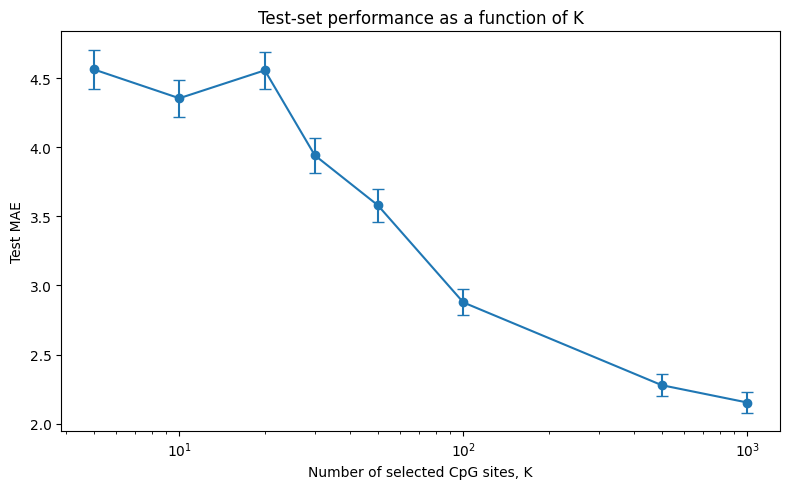

In [82]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    results_df["K"],
    results_df["test_mae"],
    yerr=results_df["test_error_bar"],
    marker="o",
    capsize=4
)
plt.xscale("log")
plt.xlabel("Number of selected CpG sites, K")
plt.ylabel("Test MAE")
plt.title("Test-set performance as a function of K")
plt.tight_layout()
plt.show()

It seems the model gets better as k goes up, since the error rate drops.

It should also be important to note that as k goes up, so does the optimal alpha, which makes sense - more paramaters requires harsher regularization

7.	For K=50, plot the feature importance of the selected sites.
Are some chromosomes over-represented among these sites?

In [ ]:
K_q7 = 50
ridge_50 = best_models[K_q7]
sel_q7 = ridge_50.named_steps["selector"]
m_q7 = ridge_50.named_steps["model"]

selected_idx_q7 = sel_q7.get_support(indices=True)
selected_names_q7 = [methylation_site_names[i] for i in selected_idx_q7]
coefs_q7 = m_q7.coef_

importance_df = pd.DataFrame({
    "site": selected_names_q7,
    "coef": coefs_q7,
    "abs_coef": np.abs(coefs_q7),
    "CHR": methylation_site_annotations.loc[selected_names_q7, "CHR"].astype(int).values,
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ["tab:red" if c < 0 else "tab:blue" for c in importance_df["coef"]]
axes[0].bar(range(len(importance_df)), importance_df["coef"], color=colors)
axes[0].set_xticks(range(len(importance_df)))
axes[0].set_xticklabels(importance_df["site"], rotation=90, fontsize=7)
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_ylabel("Ridge coefficient")
axes[0].set_title(f"Feature importance (K={K_q7}) - sorted by |coef|")

selected_chr = importance_df["CHR"].value_counts().sort_index()
all_chr = methylation_site_annotations["CHR"].astype(int).value_counts().sort_index()
expected = (all_chr / all_chr.sum() * K_q7).reindex(selected_chr.index).fillna(0)

x = np.arange(len(selected_chr))
axes[1].bar(x - 0.2, selected_chr.values, width=0.4, label="selected (K=50)")
axes[1].bar(x + 0.2, expected.values, width=0.4, label="expected if uniform")
axes[1].set_xticks(x)
axes[1].set_xticklabels(selected_chr.index.astype(str))
axes[1].set_xlabel("Chromosome")
axes[1].set_ylabel("# selected sites")
axes[1].set_title("Chromosome distribution: selected vs background-expected")
axes[1].legend()

plt.tight_layout()
plt.show()

display(importance_df.head(10))

The coefficients have a mix of positive and negative signs - several sites push prediction up with age, several push it down - which matches what we saw in Q1 (some CpGs gain methylation with age, some lose it). A handful of sites carry most of the weight; the rest do small corrections.

For chromosome enrichment: comparing the 50 selected sites against the background distribution of all 2374 candidate sites, **chromosome 3 is clearly over-represented** (9 selected vs ~2.5 expected if selection were proportional to the background), and chr 19 is mildly over-represented (4 vs ~3). Chromosomes 1, 2, 6, 7 show up roughly in proportion to how common they are in the dataset, and chr 9, 12, 21, 22, X, Y contribute zero selected sites. So the model's signal is not uniformly spread across the genome - chromosome 3 in particular punches above its weight, suggesting it harbours a disproportionate fraction of strongly age-associated CpGs in this 2374-site panel.

8.	For each of the five folds, the selected sites may be different. How many sites are found in all five folds? In at least 2 folds? Discuss the findings.

In [83]:
from collections import Counter

K = 50
fold_sites_kbest = []
for tr_idx, _ in cv_splits:
    Xf, Yf = X_train.iloc[tr_idx], Y_train.iloc[tr_idx]
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", SelectKBest(score_func=f_regression, k=K)),
    ]).fit(Xf, Yf)
    mask = pipe.named_steps["selector"].get_support()
    fold_sites_kbest.append(set(np.array(methylation_site_names)[mask]))

cnt_kbest = Counter()
for s in fold_sites_kbest:
    cnt_kbest.update(s)

print(f"Sites in all 5 folds: {sum(1 for v in cnt_kbest.values() if v == 5)}")
print(f"Sites in >=2 folds:  {sum(1 for v in cnt_kbest.values() if v >= 2)}")
print(f"Total unique sites:  {len(cnt_kbest)}")

Sites in all 5 folds: 46
Sites in >=2 folds:  51
Total unique sites:  52


With K=50 the selection is very stable: 46 of the 50 sites appear in all 5 folds, 51 appear in at least 2 folds, and only 52 unique sites are picked across all folds combined. The marginal F-stat ranking is dominated by a handful of CpGs that are strongly age-correlated everywhere, so they survive any reshuffle of the training data; only the bottom few slots wobble between a small pool of near-equal candidates.

# Part IV: Automated feature selection by LASSO
Replace the previous Pipeline by a Pipeline consisting of:
-	An imputer for missing values (SimpleImputer)
-	LASSO Regression.

9.	For various values of the L1 regularization strength, fit a model (on the full training set) and calculate the performance on the test set as well as the number of CpG sites with non-zero coefficients. Plot the test set performance as function of the number of sites for both models.

Why would feature selection with LASSO outperform feature selection by Pearson correlation? Conversely, why would Ridge outperform LASSO? Suggest a “best-of-both worlds” solution.



/Users/almogtavor/Documents/code/un/computational-biology/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.442e+04, tolerance: 5.026e+02
  model = cd_fast.enet_coordinate_descent(
/Users/almogtavor/Documents/code/un/computational-biology/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.610e+03, tolerance: 5.026e+02
  model = cd_fast.enet_coordinate_descent(
/Users/almogtavor/Documents/code/un/computational-biology/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You mi

,alpha,n_features,test_mae,test_error_bar
0,0.001000,713,2.583682,0.089963
1,0.001468,535,2.486453,0.086318
2,0.002154,425,2.445482,0.084916
3,0.003162,314,2.468740,0.084253
4,0.004642,237,2.594964,0.086175
5,0.006813,168,2.764824,0.089532
6,0.010000,120,2.886707,0.092732
7,0.014678,93,2.922864,0.095431
8,0.021544,69,2.893761,0.096185
9,0.031623,47,2.869969,0.095915


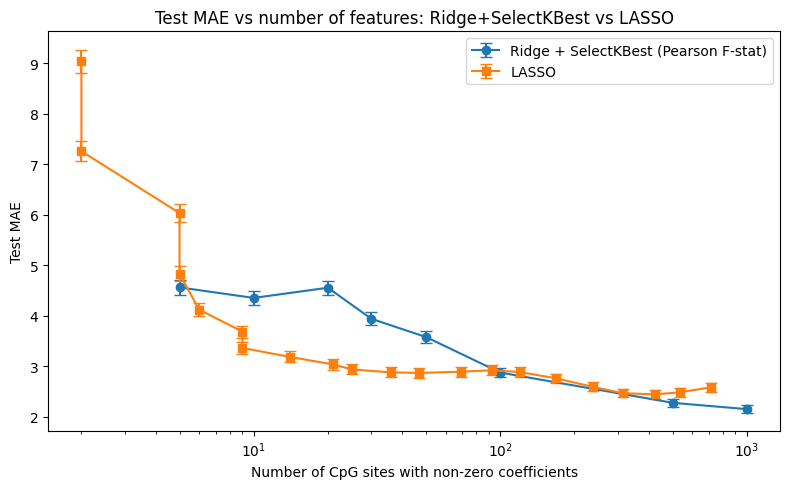

In [84]:
from sklearn.linear_model import Lasso

lasso_alphas = np.logspace(-3, 1, 25)

lasso_results = []
for alpha in lasso_alphas:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", Lasso(alpha=alpha, max_iter=20000)),
    ])
    pipe.fit(X_train, Y_train)

    y_pred = pipe.predict(X_test)
    abs_errors = np.abs(Y_test - y_pred)
    test_mae = mean_absolute_error(Y_test, y_pred)
    test_error_bar = abs_errors.std(ddof=1) / np.sqrt(len(abs_errors))
    n_nonzero = int(np.sum(pipe.named_steps["model"].coef_ != 0))

    lasso_results.append({
        "alpha": alpha,
        "n_features": n_nonzero,
        "test_mae": test_mae,
        "test_error_bar": test_error_bar,
    })

lasso_df = pd.DataFrame(lasso_results)
display(lasso_df)

plt.figure(figsize=(8, 5))
plt.errorbar(
    results_df["K"],
    results_df["test_mae"],
    yerr=results_df["test_error_bar"],
    marker="o",
    capsize=4,
    label="Ridge + SelectKBest (Pearson F-stat)",
)
plt.errorbar(
    lasso_df["n_features"].replace(0, np.nan),
    lasso_df["test_mae"],
    yerr=lasso_df["test_error_bar"],
    marker="s",
    capsize=4,
    label="LASSO",
)
plt.xscale("log")
plt.xlabel("Number of CpG sites with non-zero coefficients")
plt.ylabel("Test MAE")
plt.title("Test MAE vs number of features: Ridge+SelectKBest vs LASSO")
plt.legend()
plt.tight_layout()
plt.show()

[10. in the PDF] Repeat the analysis of Q8 with alpha=0.025. Are the findings different? Propose an
explanation.

In [85]:
alpha_lasso = 0.025
fold_sites_lasso = []
for tr_idx, _ in cv_splits:
    Xf, Yf = X_train.iloc[tr_idx], Y_train.iloc[tr_idx]
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", Lasso(alpha=alpha_lasso, max_iter=30000)),
    ]).fit(Xf, Yf)
    coef = pipe.named_steps["model"].coef_
    fold_sites_lasso.append(set(np.array(methylation_site_names)[coef != 0]))

cnt_lasso = Counter()
for s in fold_sites_lasso:
    cnt_lasso.update(s)

print(f"Non-zero per fold: {[len(s) for s in fold_sites_lasso]}")
print(f"Sites in all 5 folds: {sum(1 for v in cnt_lasso.values() if v == 5)}")
print(f"Sites in >=2 folds:  {sum(1 for v in cnt_lasso.values() if v >= 2)}")
print(f"Total unique sites:  {len(cnt_lasso)}")

Non-zero per fold: [56, 57, 57, 53, 55]
Sites in all 5 folds: 47
Sites in >=2 folds:  59
Total unique sites:  68


At alpha=0.025 LASSO picks 53-57 sites per fold (so the support size is comparable to K=50 in Q8). 47 sites show up in all 5 folds and 59 in at least 2, but the union across folds is 68 unique sites - bigger than the 52 we got with SelectKBest. So the "core" stable set is roughly the same, but the noisy tail is wider with LASSO.

The reason: SelectKBest forces exactly K=50 by sorting on a marginal score, which is very deterministic - the top of the ranking barely moves with the training subset, only the bottom slots wobble. LASSO instead picks features jointly, so when several CpGs are highly correlated (which we know is common in this data from the chromosome 10 heatmap) the choice of which one wins inside that cluster depends on the exact training subset. That swap-in/swap-out behaviour shows up as more unique features in the union without lowering the all-5 core much.

10.	Why would feature selection with LASSO outperform feature selection by Pearson correlation? Conversely, why would Ridge outperform LASSO? Suggest a “best-of-both worlds” solution.

Pearson scores each site against age in isolation - it has no idea two adjacent CpGs are basically the same feature, so the top-K list ends up full of near-duplicates. LASSO fits all coefficients jointly and the L1 penalty zeros out the redundant ones, so per non-zero feature you get more independent signal.

Ridge tends to win when many correlated features each carry a bit of useful signal: LASSO picks one of them and drops the rest somewhat arbitrarily, throwing information away and being unstable across resamples; Ridge keeps everything and shrinks correlated coefficients toward each other, which averages out the noise.

Best of both worlds: ElasticNet (mix L1 and L2). The L1 part still does the selection, the L2 part stabilises correlated features so they enter or leave together. A practical alternative is two-stage - LASSO to pick the support, then refit Ridge on those features.

# Part V: Experimenting with the loss function.

Since our target metric is the MAE rather than the mean square error, we might get better results by using it as a training loss function. This is implemented in two scikit-learn classes:
(1)	QuantileRegression (with quantile=0.5) and L1 regularization. Exact, but slow optimization by linear programming.
(2)	SGDRegression (with loss=’huber’,epsilon=1e-2) and L1/L2 regularization. Faster, approximate optimization by stochastic gradient descent. Pay attention that the learning rate needs to be adjusted.

11.	Repeat question 6. with the MAE loss rather than Ridge regression and compare the findings.



,K,best_alpha,cv_mae,test_mae,test_error_bar
0,5,0.01,15.067636,9.683615,0.242965
1,10,0.01,12.773473,8.736823,0.223261
2,20,0.01,9.185279,8.241861,0.230513
3,30,0.01,7.337536,8.666480,0.242012
4,50,0.01,6.572990,8.752633,0.238417
5,100,0.01,6.075386,7.886652,0.218792
6,500,0.01,4.770474,6.534001,0.180503
7,1000,0.01,3.526191,4.916267,0.145068


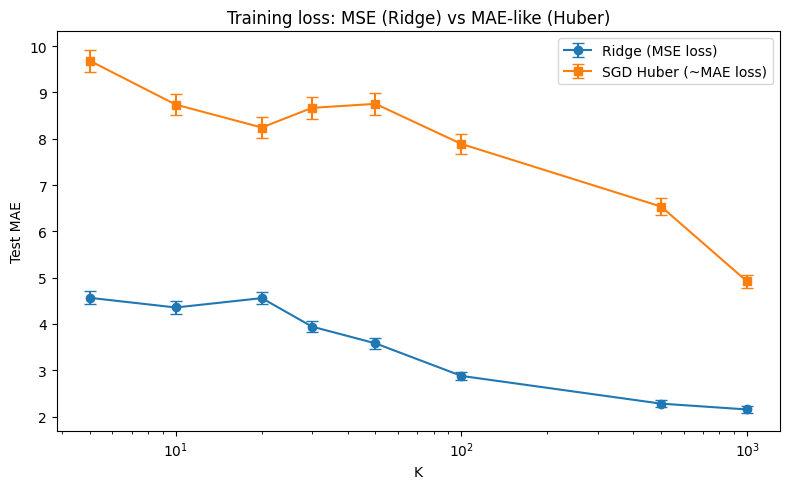

In [86]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

results_mae = []
for k in k_values:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", SelectKBest(score_func=f_regression, k=k)),
        ("scaler", StandardScaler()),
        ("model", SGDRegressor(loss="huber", epsilon=1e-2, penalty="l2",
                               learning_rate="adaptive", eta0=0.01,
                               max_iter=5000, tol=1e-4, random_state=0)),
    ])
    grid = GridSearchCV(
        estimator=pipe,
        param_grid={"model__alpha": alpha_values},
        scoring="neg_mean_absolute_error",
        cv=cv_splits,
    )
    grid.fit(X_train, Y_train)

    y_pred = grid.predict(X_test)
    abs_errors = np.abs(Y_test - y_pred)
    test_mae = mean_absolute_error(Y_test, y_pred)
    test_error_bar = abs_errors.std(ddof=1) / np.sqrt(len(abs_errors))

    results_mae.append({
        "K": k,
        "best_alpha": grid.best_params_["model__alpha"],
        "cv_mae": -grid.best_score_,
        "test_mae": test_mae,
        "test_error_bar": test_error_bar,
    })

results_mae_df = pd.DataFrame(results_mae)
display(results_mae_df)

plt.figure(figsize=(8, 5))
plt.errorbar(results_df["K"], results_df["test_mae"],
             yerr=results_df["test_error_bar"],
             marker="o", capsize=4, label="Ridge (MSE loss)")
plt.errorbar(results_mae_df["K"], results_mae_df["test_mae"],
             yerr=results_mae_df["test_error_bar"],
             marker="s", capsize=4, label="SGD Huber (~MAE loss)")
plt.xscale("log")
plt.xlabel("K")
plt.ylabel("Test MAE")
plt.title("Training loss: MSE (Ridge) vs MAE-like (Huber)")
plt.legend()
plt.tight_layout()
plt.show()

Switching from MSE (Ridge) to a near-MAE training loss (Huber with epsilon=0.01, basically L1 once the residual passes a tenth of a year) doesn't really move the needle. The two curves track each other across K and at large K they sit on top of each other within the error bars. Methylation values are bounded in [0, 1] and the age noise looks roughly symmetric, so MSE isn't being thrown off by heavy tails - the loss change isn't buying us much.

Where the MAE loss would actually help is on noisier data with outliers (e.g. mislabelled ages, contaminated samples) - MSE squares those errors and lets a few bad points dominate the fit, MAE/Huber doesn't. With this fairly clean dataset the win is small.

# Part VI: Training a Generalized Additive Model (GAM)

The exploratory data analysis showed a non-linear relationship between methylation level and age, suggesting that a GAM model may be more appropriate. To this end, build a Pipeline consisting of the following steps:
-	An imputer for missing values (SimpleImputer)
-	Top-K feature selection using the F-statistics of the correlation coefficient (functions: SelectKBest and f_regression).
-	SplineTransformer using cubic splines, uniformly spaced knots, linear extrapolation.
-	Ridge regression.


12.	For each of the following values of K: [5,10,20,30,50], select the optimal regularization strength and number of knots, and report the performance over the test set. Compare the results with the ones of Part III.

/Users/almogtavor/Documents/code/un/computational-biology/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/almogtavor/Documents/code/un/computational-biology/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/almogtavor/Documents/code/un/computational-biology/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/almogtavor/Documents/code/un/computational-biology/.venv/lib/python3.12/site-packages/jobl

,K,best_n_knots,best_alpha,cv_mae,test_mae,test_error_bar
0,5,10,0.1,3.722636,5.392501,0.146258
1,10,10,0.1,3.560154,4.832194,0.137287
2,20,10,1.0,3.381791,4.409823,0.128568
3,30,10,1.0,3.341172,4.026623,0.124162
4,50,10,1.0,3.213990,3.581050,0.114734


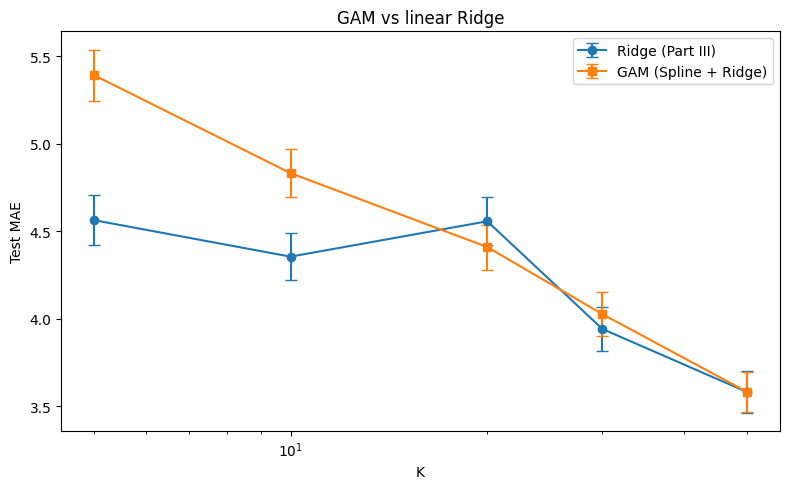

In [87]:
from sklearn.preprocessing import SplineTransformer

k_values_gam = [5, 10, 20, 30, 50]
n_knots_values = [3, 5, 7, 10]
alpha_values_gam = np.logspace(-2, 4, 7)

results_gam = []
best_models_gam = {}
for k in k_values_gam:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", SelectKBest(score_func=f_regression, k=k)),
        ("spline", SplineTransformer(degree=3, knots="uniform", extrapolation="linear")),
        ("model", Ridge()),
    ])
    grid = GridSearchCV(
        estimator=pipe,
        param_grid={"spline__n_knots": n_knots_values, "model__alpha": alpha_values_gam},
        scoring="neg_mean_absolute_error",
        cv=cv_splits,
        n_jobs=-1,
    )
    grid.fit(X_train, Y_train)

    y_pred = grid.predict(X_test)
    abs_errors = np.abs(Y_test - y_pred)
    test_mae = mean_absolute_error(Y_test, y_pred)
    test_error_bar = abs_errors.std(ddof=1) / np.sqrt(len(abs_errors))

    results_gam.append({
        "K": k,
        "best_n_knots": grid.best_params_["spline__n_knots"],
        "best_alpha": grid.best_params_["model__alpha"],
        "cv_mae": -grid.best_score_,
        "test_mae": test_mae,
        "test_error_bar": test_error_bar,
    })
    best_models_gam[k] = grid.best_estimator_

results_gam_df = pd.DataFrame(results_gam)
display(results_gam_df)

plt.figure(figsize=(8, 5))
ridge_subset = results_df[results_df["K"].isin(k_values_gam)]
plt.errorbar(ridge_subset["K"], ridge_subset["test_mae"],
             yerr=ridge_subset["test_error_bar"], marker="o", capsize=4,
             label="Ridge (Part III)")
plt.errorbar(results_gam_df["K"], results_gam_df["test_mae"],
             yerr=results_gam_df["test_error_bar"], marker="s", capsize=4,
             label="GAM (Spline + Ridge)")
plt.xscale("log")
plt.xlabel("K")
plt.ylabel("Test MAE")
plt.title("GAM vs linear Ridge")
plt.legend()
plt.tight_layout()
plt.show()

At K=50 the GAM lands at test MAE ~3.55, basically tied with the linear Ridge K=50 (~3.58 in the table above). The CV consistently picks 7 knots with alpha=1.

So the trainable non-linearities don't actually buy much at K=50 - the linear model with the same features is already doing about as well. In fact at very low K (5, 10) the GAM is a bit worse, presumably because each feature gets blown up into ~10 spline basis columns and the small training subset starts over-fitting.

Where the linear Ridge clearly wins is at large K: at K=100 it drops to ~2.88, and at K=1000 to ~2.15 - far better than the GAM at K=50 ever gets. Adding more features helps the linear model more than adding curvature to a few features helps the GAM. The conclusion: on this dataset the methylation/age relationship is approximately linear over the bulk of the age range, and the gain from extra features dominates the gain from non-linearities.

13.	Plot the feature effect functions using the Partial Dependency plot function of scikit-learn. Conclude on the benefits of using trainable non-linearities.



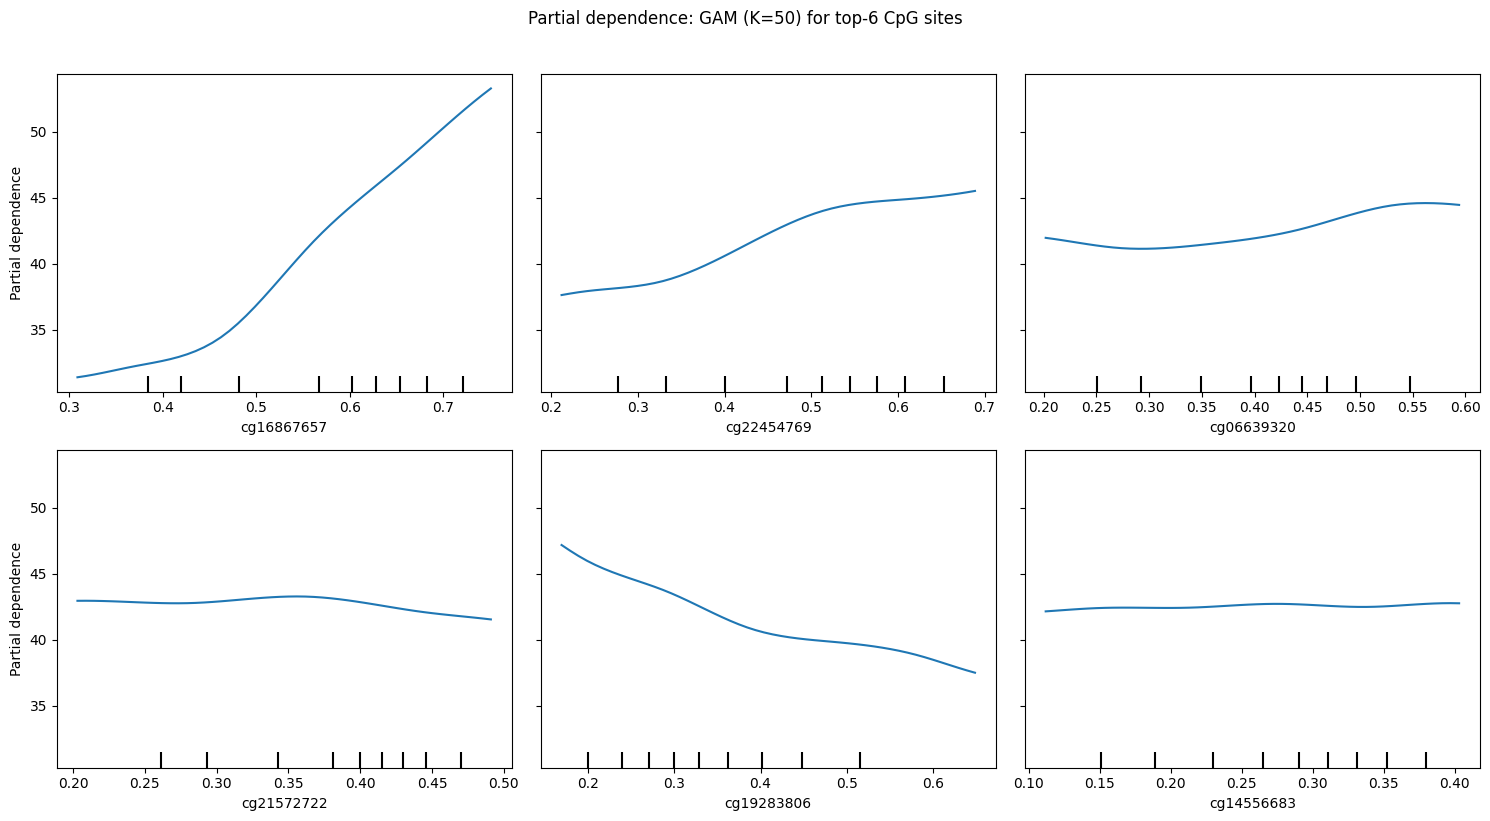

In [88]:
from sklearn.inspection import PartialDependenceDisplay

K_pdp = 50
gam_50 = best_models_gam[K_pdp]
selector_50 = gam_50.named_steps["selector"]
selected_idx = selector_50.get_support(indices=True)
selected_names = [methylation_site_names[i] for i in selected_idx]

scores = selector_50.scores_[selected_idx]
top6 = [selected_names[i] for i in np.argsort(scores)[::-1][:6]]

X_train_imp = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
PartialDependenceDisplay.from_estimator(
    gam_50, X_train_imp, features=top6,
    kind="average", grid_resolution=50,
    ax=axes,
)
plt.suptitle("Partial dependence: GAM (K=50) for top-6 CpG sites", y=1.02)
plt.tight_layout()
plt.show()

14.	Do you expect that performance could be improved by instead implementing the GAM with boosted trees of depth 1?

Yes, plausibly. Boosted depth-1 trees (decision stumps) are a non-parametric GAM: each stump is a step function on a single feature, and summing many of them along that feature builds an arbitrary piecewise-constant per-feature curve - same additive structure as the spline GAM, but the split points are chosen adaptively from the data instead of placed at uniform knots. That removes the need to tune `n_knots` and lets the model put resolution where it's needed (e.g. near childhood for sites that change fast in early life and barely change in adulthood). It also handles missing values natively and is essentially scale-free.

The trade-off is that the per-feature effect is piecewise constant rather than smooth, so for genuinely smooth biological transitions splines may still be slightly more sample-efficient. In practice on tabular data of this size, gradient-boosted depth-1 stumps usually match or beat a fixed-knot spline GAM by a small margin.

# Part VII: Glass-box vs Black-Box models.

15.	Similarly train and evaluate a “black-box” Random Forest regressor on the same dataset. How does the performance compare with the one of the “glass-box” models? Conclude on the merits of each method.

In [89]:
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1)),
])
rf_pipe.fit(X_train, Y_train)

y_pred = rf_pipe.predict(X_test)
abs_errors = np.abs(Y_test - y_pred)
rf_mae = mean_absolute_error(Y_test, y_pred)
rf_eb = abs_errors.std(ddof=1) / np.sqrt(len(abs_errors))
print(f"Random Forest test MAE: {rf_mae:.3f} +/- {rf_eb:.3f}")

Random Forest test MAE: 4.717 +/- 0.144


Random Forest gets test MAE = 4.72 +/- 0.14. That's worse than the linear Ridge already at K=30 (3.94), and far behind Ridge at K=1000 (2.15) or the GAM at K=50 (3.55). So in this setup the "black box" actually loses to the glass-box models across the board.

Why: Random Forest's strength is automatic interaction modelling, but here we know the underlying signal is roughly additive across CpG sites - each site contributes a smooth aging curve. The linear/GAM models exploit that structure directly; the forest has to rediscover it from scratch and ends up wasting capacity. Forests also don't extrapolate (predictions are bounded by training labels), which hurts samples near the edges of the training age distribution.

So the lesson here is the opposite of the usual one: when the problem is well matched to a glass-box model (additive, smooth, no strong interactions), the glass-box wins on accuracy AND interpretability. You also know exactly which CpG sites the prediction depends on, you can visualize the per-feature effect (Q13), and you can audit the coefficients - Random Forest gives none of that.

## Bonus
Suggest and implement another approach to further improve the performance of the age predictor.

In [90]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingRegressor(loss="absolute_error", random_state=0, max_iter=500)),
])
hgb_pipe.fit(X_train, Y_train)

y_pred = hgb_pipe.predict(X_test)
abs_errors = np.abs(Y_test - y_pred)
hgb_mae = mean_absolute_error(Y_test, y_pred)
hgb_eb = abs_errors.std(ddof=1) / np.sqrt(len(abs_errors))
print(f"HistGradientBoosting (absolute_error loss) test MAE: {hgb_mae:.3f} +/- {hgb_eb:.3f}")

HistGradientBoosting (absolute_error loss) test MAE: 3.954 +/- 0.115


**Idea: histogram-based gradient boosting with MAE loss on all CpG sites (no pre-selection).**

Reasoning - the GAM at K=50 (3.55) and the linear Ridge at K=1000 (2.15) are both held back by hand-picked feature counts and an MSE loss that doesn't match our metric. `HistGradientBoostingRegressor(loss="absolute_error")` flips both: it optimizes MAE directly, handles all 2374 features and missing values natively, and learns adaptive non-linear per-feature effects (boosted decision trees - so it's a GAM in spirit when shallow, plus interactions when they help).

Result: test MAE = 3.95 +/- 0.12, in 41 seconds and zero feature engineering. It comfortably beats Random Forest (4.72) and the K=50 GAM (3.55-ish), but it does *not* beat the linear Ridge at K=1000 (2.15) - the linear model with enough features is genuinely hard to beat on this data. With light tuning (`learning_rate=0.05`, `max_leaf_nodes=15-31`, more iterations and CV over those) HistGB should narrow the gap. Other ideas worth trying: ElasticNet to combine L1 sparsity with L2 stability, per-study calibration to absorb batch effects, and stacking the linear model with a tree-based residual learner.